In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from google.colab import drive

In [ ]:
drive.mount('/content/drive')
pd.set_option('display.max_columns', None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2024-2025个人欺诈

In [ ]:
# Experience of scams in the last 12 months, By selected scam types
df8a = pd.read_excel(
    '/content/drive/MyDrive/LSJM/Personal Fraud (Tables 1a to 13b).xlsx',
    sheet_name='Table 8a',
    header=None
)

scam_names = df8a.iloc[8:15, 0].reset_index(drop=True)
rates_2024_25 = df8a.iloc[8:15, 10].reset_index(drop=True)

result = pd.DataFrame({
    'Scam type': scam_names,
    'Rate 2024-25 (%)': rates_2024_25
})

print(result)

                         Scam type Rate 2024-25 (%)
0  Information request or phishing              0.5
1                 Computer support              0.1
2                 Financial advice              0.3
3                  Upfront payment              0.3
4                Buying or selling              1.4
5          Relationship or romance              0.1
6             Threats or extortion              0.1


In [ ]:
# Persons of scams in the last 12 months, By selected scam types
df9a = pd.read_excel(
    '/content/drive/MyDrive/LSJM/Personal Fraud (Tables 1a to 13b).xlsx',
    sheet_name='Table 9a',
    header=None
)

scam_names = df9a.iloc[8:15, 0].reset_index(drop=True)
rates_2024_25 = df9a.iloc[8:15, 2].reset_index(drop=True)

result = pd.DataFrame({
    'Scam type': scam_names,
    'Rate 2024-25 (%)': rates_2024_25
})

print(result)

                 Scam type Rate 2024-25 (%)
0         Computer support              2.4
1         Financial advice             11.6
2          Upfront payment             11.2
3        Buying or selling             51.4
4  Relationship or romance              2.5
5     Threats or extortion              2.6
6                 Other(b)                4


### 2025 欺诈数据

In [ ]:
# Amount of Money Sorting

file_path = "/content/drive/My Drive/LSJM/2025scamwatch.xlsx"
sheet_name = "Sheet2"

df = pd.read_excel(file_path, sheet_name=sheet_name)

# 只保留需要的列
df = df[["Scam Type", "Total", "Percentage"]].copy()

# 删掉空值
df = df.dropna(subset=["Scam Type", "Total"])

# 去掉“总计”这一行
df = df[df["Scam Type"] != "Total Amount"]

# 如果金额列是字符串，转成数值
df["Total"] = (
    df["Total"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["Total"] = pd.to_numeric(
    df["Total"], errors="coerce"
)
# 按百分比降序排序
df = df.sort_values(by="Percentage", ascending=False).reset_index(drop=True)

# 美化显示格式
display_df = df.copy()
display_df["Total"] = display_df["Total"].map(lambda x: f"${x:,.2f}")
display_df["Percentage"] = display_df["Percentage"].map(lambda x: f"{x*100:.2f}%")

# 打印整齐表格
print("\nScam type summary\n")
print(display_df.to_string(index=False))


Scam type summary

                          Scam Type           Total Percentage
                   Investment scams $119,243,620.10     49.94%
                           Phishing  $23,980,230.07     10.04%
           Dating and romance scams  $22,293,925.81      9.34%
                      False billing  $17,757,983.04      7.44%
          Jobs and employment scams  $16,418,717.37      6.88%
   Threats to life, arrest or other  $10,289,330.92      4.31%
                     Shopping scams   $7,579,960.43      3.17%
                     Identity theft   $5,488,378.98      2.30%
                Remote access scams   $3,844,154.19      1.61%
   inheritance and unexpected money   $2,925,531.95      1.23%
                       Rebate scams   $2,817,936.91      1.18%
Betting and sports investment scams   $1,484,059.36      0.62%
            Psychic and clairvoyant   $1,387,633.65      0.58%
                            Hacking     $759,131.88      0.32%
   Travel, prizes and lottery scams

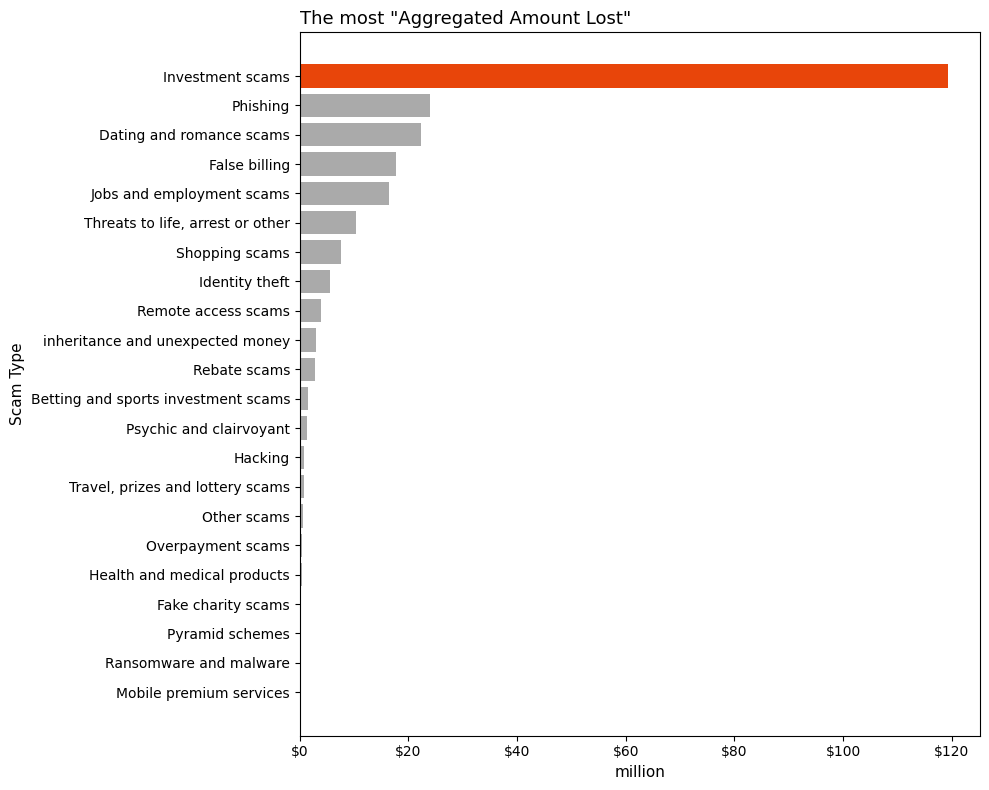

In [ ]:
# 用df里的数据（已经是数值型的Total）
plot_df = df.sort_values(by="Total", ascending=True)

# Investment scams 橙色，其他灰色
colors = ["#E8450A" if s == "Investment scams" else "#AAAAAA" for s in plot_df["Scam Type"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["Scam Type"], plot_df["Total"] / 1_000_000, color=colors)

# X轴格式
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))
ax.set_xlabel("million", fontsize=11)
ax.set_ylabel("Scam Type", fontsize=11)

ax.set_title(
    'The most "Aggregated Amount Lost"',
    fontsize=13, loc="left"
)

plt.tight_layout()
plt.show()

In [ ]:
# Amount of Money Sorting

file_path = "/content/drive/My Drive/LSJM/2025scamwatch.xlsx"
sheet_name = "Sheet1"

df = pd.read_excel(file_path, sheet_name=sheet_name)

# 只保留需要的列
df = df[["Scam Category", "Total", "Percentage"]].copy()

# 删掉空值
df = df.dropna(subset=["Scam Category", "Total"])
df = df[~df["Scam Category"].str.strip().isin(["Tota", "Total Amount"])]

# 如果金额列是字符串，转成数值
df["Total"] = (
    df["Total"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["Total"] = pd.to_numeric(
    df["Total"], errors="coerce"
)
# 按百分比降序排序
df = df.sort_values(by="Percentage", ascending=False).reset_index(drop=True)

# 美化显示格式
display_df = df.copy()
display_df["Total"] = display_df["Total"].map(lambda x: f"${x:,.2f}")
display_df["Percentage"] = display_df["Percentage"].map(lambda x: f"{x*100:.2f}%")

# 打印整齐表格
print("\nScam type summary\n")
print(display_df.to_string(index=False))


Scam type summary

                             Scam Category      Total Percentage
Attempts to gain your personal information $73,832.00     51.18%
                         Buying or selling $31,116.00     21.57%
                                     Other $14,695.00     10.19%
                     Threats and extortion  $6,664.00      4.62%
                          Investment scams  $5,150.00      3.57%
                       Jobs and employment  $4,977.00      3.45%
                          Unexpected money  $2,845.00      1.97%
                        Dating and romance  $2,288.00      1.59%
                       Unexpected winnings  $2,098.00      1.45%
                            Fake charities    $602.00      0.42%


/tmp/ipykernel_415/3071731476.py:12: UserWarning: Glyph 21315 (\N{CJK UNIFIED IDEOGRAPH-5343}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21315 (\N{CJK UNIFIED IDEOGRAPH-5343}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


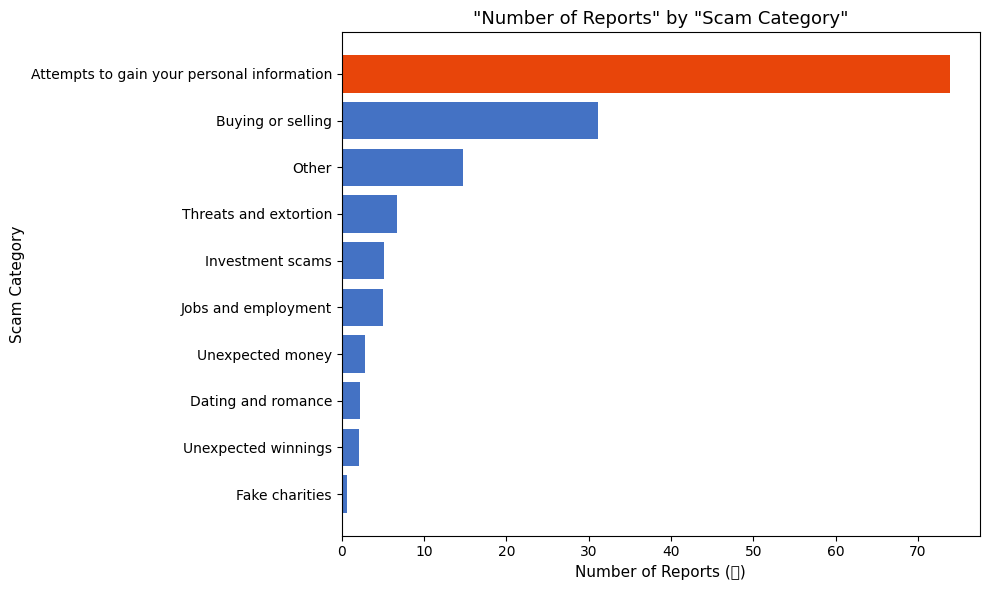

In [ ]:
plot_df = df.sort_values(by="Total", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
max_cat = plot_df["Scam Category"].iloc[-1]  # 排序后最后一个是最大值
colors = ["#E8450A" if s == max_cat else "#4472C4" for s in plot_df["Scam Category"]]
ax.barh(plot_df["Scam Category"], plot_df["Total"] / 1000, color=colors)

ax.set_xlabel("Number of Reports (千)", fontsize=11)
ax.set_ylabel("Scam Category", fontsize=11)
ax.set_title('"Number of Reports" by "Scam Category"', fontsize=13)

plt.tight_layout()
plt.show()

### 欺诈网站URL检索和分析



In [ ]:
import os
import pandas as pd
from google.colab import drive

# 挂载云端硬盘
drive.mount('/content/drive')
path = "/content/drive/MyDrive/LSJM/verified_online.csv"

# 检查文件是否存在
if os.path.exists(path):
    try:
        # 尝试使用 ISO-8859-1 编码读取，解决 UnicodeDecodeError
        df = pd.read_csv(path, encoding='ISO-8859-1')
        print("Original shape:", df.shape)

        # 只保留需要的列
        cols_to_keep = ["phish_id", "url", "target"]
        # 确保列名存在于数据中
        df = df[[col for col in cols_to_keep if col in df.columns]]

        # 数据清洗
        df = df.drop_duplicates(subset="url").dropna(subset=["url"])

        print("After cleaning:", df.shape)
        display(df.head())
    except Exception as e:
        print(f"读取文件时出错: {e}")
else:
    print(f"错误：找不到文件 {path}")
    parent_dir = "/content/drive/MyDrive/LSJM/"
    if os.path.exists(parent_dir):
        print(f"目录 {parent_dir} 下的文件有：\n", os.listdir(parent_dir))
    else:
        print("请确认 Google Drive 路径是否正确。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
错误：找不到文件 /content/drive/MyDrive/LSJM/url dataset.csv
目录 /content/drive/MyDrive/LSJM/ 下的文件有：
 ['Data item list.xlsx', 'Personal Fraud (Tables 1a to 13b).xlsx', 'LSJM_Python.ipynb', '2025scamwatch.xlsx', 'verified_online.csv']


#### URL特征提取


Extended feature columns added successfully.


,phish_id,url,target,registered_domain,url_length,url_depth,has_ip,matched_words,matched_word_count,hostname_length,...,has_percent_encoding,query_symbol_count,is_https,digit_count,letter_count,special_char_count,digit_ratio,letter_ratio,special_char_ratio,entropy
0,9366067,https://copy-of-rhode-gift-card-lan-436.create...,Other,created.app,52,0,0,[gift],1,43,...,0,0,1,3,37,12,0.057692,0.711538,0.230769,4.276611
1,9366053,https://allegrolokalnie.pl-oferta2508073.click,Allegro,pl-oferta2508073.click,46,0,0,[],0,38,...,0,0,1,7,33,6,0.152174,0.717391,0.130435,4.425098
2,9366052,http://allegro.pl-822718181826zamowienie272728...,Allegro,pl-822718181826zamowienie272728m7162728.lat,58,0,0,[],0,51,...,0,0,0,25,27,6,0.431034,0.465517,0.103448,4.213428
3,9366051,http://allegro.pl-oferta57723.click,Allegro,pl-oferta57723.click,35,0,0,[],0,28,...,0,0,0,5,24,6,0.142857,0.685714,0.171429,4.250572
4,9366050,http://allegrolokalnie.pl-591248129512.cyou,Allegro,pl-591248129512.cyou,43,0,0,[],0,36,...,0,0,0,12,25,6,0.279070,0.581395,0.139535,4.452444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9365956,https://docs.google.com/drawings/d/1MVFdzDcAhH...,Other,google.com,84,4,0,[],0,15,...,0,0,1,6,67,11,0.071429,0.797619,0.130952,5.258289
96,9365955,https://docs.google.com/drawings/d/1QrJpIW-Je9...,Other,google.com,84,4,0,[],0,15,...,0,0,1,12,62,10,0.142857,0.738095,0.119048,5.035017
97,9365954,https://docs.google.com/drawings/d/1kUtY10Vf37...,Other,google.com,84,4,0,[],0,15,...,0,0,1,10,65,9,0.119048,0.773810,0.107143,5.216199
98,9365953,https://docs.google.com/drawings/d/1eCEKNe0zXk...,Other,google.com,84,4,0,[],0,15,...,0,0,1,10,65,9,0.119048,0.773810,0.107143,5.158404



=== Descriptive Statistics ===
         url_length  hostname_length   path_length  query_length  \
count  56586.000000     56586.000000  56586.000000  56586.000000   
mean      60.784505        19.299403     20.648217     11.603524   
std      165.647485        12.980359     34.178536     50.711620   
min       12.000000         0.000000      0.000000      0.000000   
25%       23.000000         8.000000      1.000000      0.000000   
50%       38.000000        16.000000      7.000000      0.000000   
75%       62.000000        25.000000     20.000000      0.000000   
max    25523.000000       110.000000    997.000000   3624.000000   

          url_depth  subdomain_count     dot_count  hyphen_count  \
count  56586.000000     56586.000000  56586.000000  56586.000000   
mean       1.379440         0.750875      1.972149      0.795815   
std        1.575426         0.575686      1.028034      1.397070   
min        0.000000         0.000000      1.000000      0.000000   
25%        0.00

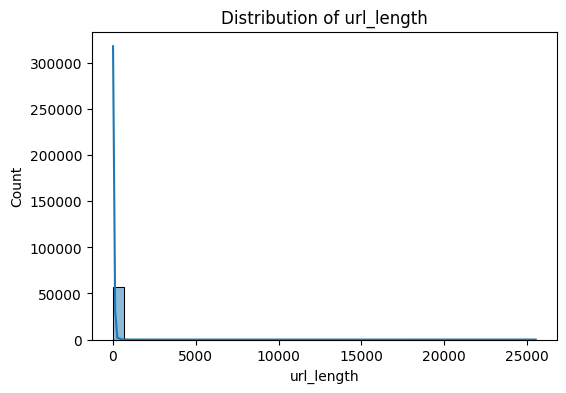

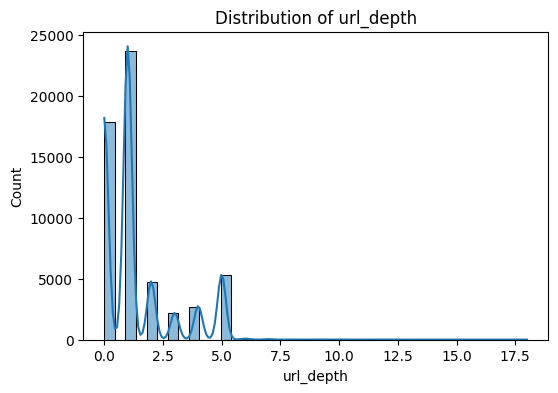

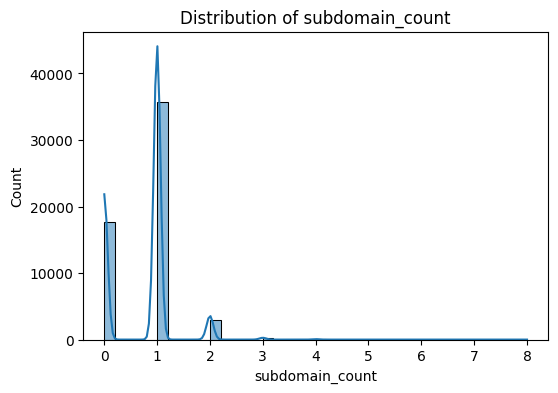

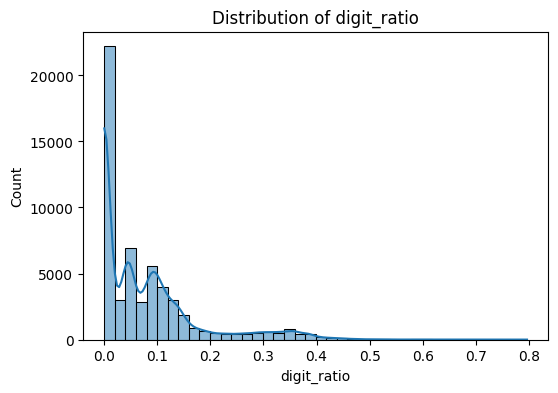

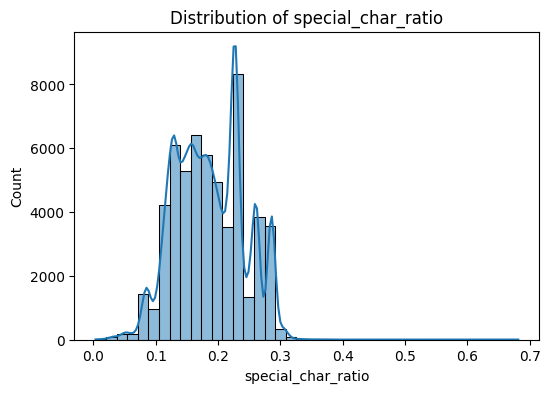

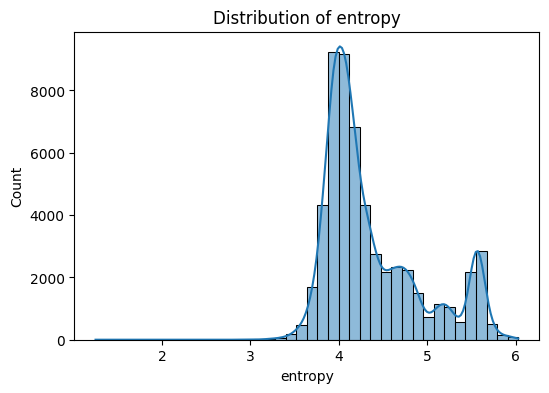

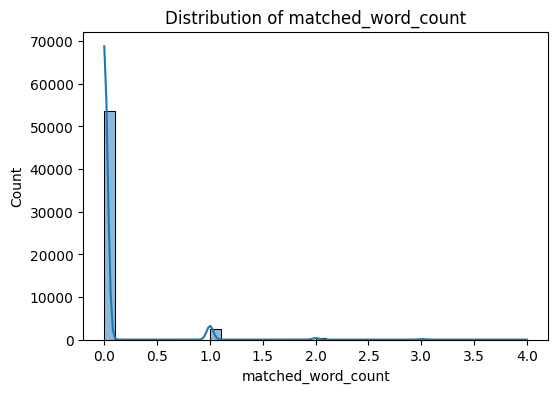

In [ ]:
# =========================
# Step 2: URL Feature Extraction + Extended Lexical Analysis
# =========================

from urllib.parse import urlparse
import tldextract
import re
import pandas as pd
import math
from collections import Counter

# -------------------------
# 1. High-frequency suspicious words
# -------------------------
HIGH_FREQ_WORDS = [
    "login", "verify", "secure", "update", "account",
    "signin", "confirm", "bank", "wallet", "payment",
    "delivery", "tracking", "parcel", "gift", "reward",
    "crypto", "investment", "support", "alert", "suspend"
]

# -------------------------
# 2. Basic helper
# -------------------------
def safe_parse(url):
    """
    Safely parse URL. Return ParseResult or None.
    """
    if not isinstance(url, str) or not url.strip():
        return None
    try:
        return urlparse(url)
    except Exception:
        return None


def get_hostname(url):
    """
    Return hostname without port.
    """
    parsed = safe_parse(url)
    if parsed and parsed.netloc:
        return parsed.netloc.split(":")[0].lower()
    return ""


def get_path(url):
    parsed = safe_parse(url)
    return parsed.path if parsed else ""


def get_query(url):
    parsed = safe_parse(url)
    return parsed.query if parsed else ""


# -------------------------
# 3. Existing / improved functions
# -------------------------
def domain_of_url(url):
    """
    Return the registered domain, e.g.
    https://login.paypal-secure.top/a -> paypal-secure.top
    """
    if not isinstance(url, str):
        return ""
    ext = tldextract.extract(url)
    if ext.domain and ext.suffix:
        return f"{ext.domain}.{ext.suffix}"
    elif ext.domain:
        return ext.domain
    else:
        return ""


def length_of_url(url):
    """
    Return total URL length.
    """
    if not isinstance(url, str):
        return 0
    return len(url)


def depth_of_url(url):
    """
    Return URL path depth.
    Example:
    https://a.com/aa/bb/cc -> 3
    https://a.com -> 0
    """
    path = get_path(url)
    parts = [p for p in path.split("/") if p]
    return len(parts)


def ip_address_in_url(url):
    """
    Return 1 if URL contains an IPv4 address, else 0.
    """
    if not isinstance(url, str):
        return 0

    pattern = r'(https?://)?(\d{1,3}\.){3}\d{1,3}'
    return 1 if re.search(pattern, url) else 0


def high_freq_words_in_url(url, word_list=HIGH_FREQ_WORDS):
    """
    Return matched suspicious/high-frequency words in URL as a list.
    """
    if not isinstance(url, str):
        return []

    url_lower = url.lower()
    matched = [word for word in word_list if word in url_lower]
    return matched


# =========================================================
# Category 1: Length-based features
# =========================================================
def hostname_length(url):
    return len(get_hostname(url))


def path_length(url):
    return len(get_path(url))


def query_length(url):
    return len(get_query(url))


# =========================================================
# Category 2: Structural features
# =========================================================
def subdomain_count(url):
    """
    Count number of subdomain parts.
    Example:
    a.b.example.com -> 2   (a, b)
    example.com -> 0
    """
    if not isinstance(url, str):
        return 0

    ext = tldextract.extract(url)
    if not ext.subdomain:
        return 0
    return len([x for x in ext.subdomain.split(".") if x])


def dot_count(url):
    if not isinstance(url, str):
        return 0
    return url.count(".")


def hyphen_count(url):
    if not isinstance(url, str):
        return 0
    return url.count("-")


def underscore_count(url):
    if not isinstance(url, str):
        return 0
    return url.count("_")


def slash_count(url):
    """
    Count all '/' in the full URL.
    """
    if not isinstance(url, str):
        return 0
    return url.count("/")


# =========================================================
# Category 3: Symbol / abnormal-format features
# =========================================================
def has_at_symbol(url):
    if not isinstance(url, str):
        return 0
    return 1 if "@" in url else 0


def has_double_slash_in_path(url):
    """
    Detect '//' appearing after scheme part.
    Example:
    https://a.com//login -> 1
    """
    if not isinstance(url, str):
        return 0

    parsed = safe_parse(url)
    if not parsed:
        return 0

    path_part = parsed.path
    return 1 if "//" in path_part else 0


def has_percent_encoding(url):
    if not isinstance(url, str):
        return 0
    return 1 if "%" in url else 0


def count_query_symbols(url):
    """
    Count ?, =, & as a rough proxy for query complexity.
    """
    if not isinstance(url, str):
        return 0
    return url.count("?") + url.count("=") + url.count("&")


def is_https(url):
    parsed = safe_parse(url)
    if not parsed:
        return 0
    return 1 if parsed.scheme.lower() == "https" else 0


# =========================================================
# Category 4: Character composition features
# =========================================================
def digit_count(url):
    if not isinstance(url, str):
        return 0
    return sum(c.isdigit() for c in url)


def letter_count(url):
    if not isinstance(url, str):
        return 0
    return sum(c.isalpha() for c in url)


def special_char_count(url):
    """
    Count non-alphanumeric characters.
    """
    if not isinstance(url, str):
        return 0
    return sum(not c.isalnum() for c in url)


def digit_ratio(url):
    if not isinstance(url, str) or len(url) == 0:
        return 0
    return digit_count(url) / len(url)


def letter_ratio(url):
    if not isinstance(url, str) or len(url) == 0:
        return 0
    return letter_count(url) / len(url)


def special_char_ratio(url):
    if not isinstance(url, str) or len(url) == 0:
        return 0
    return special_char_count(url) / len(url)


def shannon_entropy(url):
    """
    Compute Shannon entropy of the URL string.
    Higher entropy often means more randomness / obfuscation.
    """
    if not isinstance(url, str) or len(url) == 0:
        return 0

    counts = Counter(url)
    probs = [count / len(url) for count in counts.values()]
    return -sum(p * math.log2(p) for p in probs if p > 0)


# -------------------------
# 4. Apply feature extraction to the dataset
# -------------------------
df["registered_domain"] = df["url"].apply(domain_of_url)

# Category 1: Length features
df["url_length"] = df["url"].apply(length_of_url)
df["hostname_length"] = df["url"].apply(hostname_length)
df["path_length"] = df["url"].apply(path_length)
df["query_length"] = df["url"].apply(query_length)

# Category 2: Structural features
df["url_depth"] = df["url"].apply(depth_of_url)
df["subdomain_count"] = df["url"].apply(subdomain_count)
df["dot_count"] = df["url"].apply(dot_count)
df["hyphen_count"] = df["url"].apply(hyphen_count)
df["underscore_count"] = df["url"].apply(underscore_count)
df["slash_count"] = df["url"].apply(slash_count)

# Category 3: Symbol / abnormal-format features
df["has_ip"] = df["url"].apply(ip_address_in_url)
df["has_at"] = df["url"].apply(has_at_symbol)
df["has_double_slash_path"] = df["url"].apply(has_double_slash_in_path)
df["has_percent_encoding"] = df["url"].apply(has_percent_encoding)
df["query_symbol_count"] = df["url"].apply(count_query_symbols)
df["is_https"] = df["url"].apply(is_https)

# Category 4: Character composition features
df["digit_count"] = df["url"].apply(digit_count)
df["letter_count"] = df["url"].apply(letter_count)
df["special_char_count"] = df["url"].apply(special_char_count)
df["digit_ratio"] = df["url"].apply(digit_ratio)
df["letter_ratio"] = df["url"].apply(letter_ratio)
df["special_char_ratio"] = df["url"].apply(special_char_ratio)
df["entropy"] = df["url"].apply(shannon_entropy)

# Suspicious words
df["matched_words"] = df["url"].apply(high_freq_words_in_url)
df["matched_word_count"] = df["matched_words"].apply(len)

print("Extended feature columns added successfully.")
display(df.head(100))



# -------------------------
# 5. Basic descriptive statistics
# -------------------------
selected_cols = [
    "url_length", "hostname_length", "path_length", "query_length",
    "url_depth", "subdomain_count", "dot_count", "hyphen_count",
    "underscore_count", "slash_count",
    "has_ip", "has_at", "has_double_slash_path", "has_percent_encoding",
    "query_symbol_count", "is_https",
    "digit_count", "letter_count", "special_char_count",
    "digit_ratio", "letter_ratio", "special_char_ratio",
    "entropy", "matched_word_count"
]

print("\n=== Descriptive Statistics ===")
print(df[selected_cols].describe())

print("\n=== Binary Feature Rates (%) ===")
binary_cols = ["has_ip", "has_at", "has_double_slash_path", "has_percent_encoding", "is_https"]
for col in binary_cols:
    print(f"{col}: {df[col].mean() * 100:.2f}%")



import matplotlib.pyplot as plt
import seaborn as sns

num_cols_to_plot = [
    "url_length", "url_depth", "subdomain_count",
    "digit_ratio", "special_char_ratio", "entropy",
    "matched_word_count"
]

for col in num_cols_to_plot:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### 欺诈文本分析

In [ ]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

path = "/content/drive/MyDrive/LSJM/url dataset.csv"

df = pd.read_csv(path, encoding="ISO-8859-1")
print("原始数据大小:", df.shape)
print(df.columns.tolist())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
原始数据大小: (56568, 8)
['phish_id', 'url', 'phish_detail_url', 'submission_time', 'verified', 'verification_time', 'online', 'target']


,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
0,9366332,https://8iosi83.sbs/vea9iitc/B15zIm/tNbgrc,http://www.phishtank.com/phish_detail.php?phis...,2026-03-13T13:09:27+00:00,yes,2026-03-13T13:12:35+00:00,yes,Other
1,9366330,https://ay.domapoalhostarseruuizo.sbs/4cEJs-Px...,http://www.phishtank.com/phish_detail.php?phis...,2026-03-13T13:07:10+00:00,yes,2026-03-13T13:12:35+00:00,yes,Other
2,9366328,https://ay.domapoalhostarseruuizo.sbs/index.html,http://www.phishtank.com/phish_detail.php?phis...,2026-03-13T13:06:35+00:00,yes,2026-03-13T13:12:35+00:00,yes,Other
3,9366304,https://klelnanzeigen-deutch.tmtyjg.com/357785...,http://www.phishtank.com/phish_detail.php?phis...,2026-03-13T12:52:16+00:00,yes,2026-03-13T13:03:05+00:00,yes,Other
4,9366300,https://asaplayorn.wixsite.com/my-site-1,http://www.phishtank.com/phish_detail.php?phis...,2026-03-13T12:51:14+00:00,yes,2026-03-13T13:03:05+00:00,yes,Other


In [ ]:
# 只保留需要的列
cols_to_keep = ["phish_id", "url", "target", "online", "verified"]
df = df[[col for col in cols_to_keep if col in df.columns]].copy()

# 只保留 online=yes, verified=yes
if "online" in df.columns:
    df = df[df["online"].astype(str).str.lower() == "yes"]

if "verified" in df.columns:
    df = df[df["verified"].astype(str).str.lower() == "yes"]

# 去掉空 url + 去重
df = df.dropna(subset=["url"]).drop_duplicates(subset=["url"]).reset_index(drop=True)

print("清洗后数据大小:", df.shape)

# 取前1000个
df_1000 = df.head(1000).copy()
urls = df_1000["url"].tolist()

print("用于后续抓取的 URL 数量:", len(urls))
df_1000.head()

清洗后数据大小: (56561, 5)
用于后续抓取的 URL 数量: 1000


,phish_id,url,target,online,verified
0,9366332,https://8iosi83.sbs/vea9iitc/B15zIm/tNbgrc,Other,yes,yes
1,9366330,https://ay.domapoalhostarseruuizo.sbs/4cEJs-Px...,Other,yes,yes
2,9366328,https://ay.domapoalhostarseruuizo.sbs/index.html,Other,yes,yes
3,9366304,https://klelnanzeigen-deutch.tmtyjg.com/357785...,Other,yes,yes
4,9366300,https://asaplayorn.wixsite.com/my-site-1,Other,yes,yes


In [ ]:
!pip install beautifulsoup4 lxml tldextract
import time
import requests
import urllib3
from bs4 import BeautifulSoup

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"
})

def fetch_page(url, timeout=15):
    try:
        resp = session.get(
            url,
            timeout=timeout,
            allow_redirects=True,
            verify=False
        )
        return {
            "original_url": url,
            "final_url": resp.url,
            "status_code": resp.status_code,
            "html": resp.text[:1000000],
            "error": None
        }
    except Exception as e:
        return {
            "original_url": url,
            "final_url": None,
            "status_code": None,
            "html": None,
            "error": str(e)
        }

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 2.9 MB/s eta 0:00:00


In [ ]:
test_urls = urls[:20]

results = []
for i, url in enumerate(test_urls, 1):
    print(f"抓取 {i}/{len(test_urls)}")
    row = fetch_page(url)
    results.append(row)
    time.sleep(1)

df_pages = pd.DataFrame(results)
df_pages[["original_url", "final_url", "status_code", "error"]].head(10)

抓取 1/20
抓取 2/20
抓取 3/20
抓取 4/20
抓取 5/20
抓取 6/20
抓取 7/20
抓取 8/20
抓取 9/20
抓取 10/20
抓取 11/20
抓取 12/20
抓取 13/20
抓取 14/20
抓取 15/20
抓取 16/20
抓取 17/20
抓取 18/20
抓取 19/20
抓取 20/20


,original_url,final_url,status_code,error
0,https://8iosi83.sbs/vea9iitc/B15zIm/tNbgrc,https://8iosi83.sbs/vea9iitc/B15zIm/tNbgrc,200,None
1,https://ay.domapoalhostarseruuizo.sbs/4cEJs-Px...,https://ay.domapoalhostarseruuizo.sbs/4cEJs-Px...,520,None
2,https://ay.domapoalhostarseruuizo.sbs/index.html,https://ay.domapoalhostarseruuizo.sbs/index.html,520,None
3,https://klelnanzeigen-deutch.tmtyjg.com/357785...,https://klelnanzeigen-deutch.tmtyjg.com/357785...,403,None
4,https://asaplayorn.wixsite.com/my-site-1,https://asaplayorn.wixsite.com/my-site-1,404,None
5,https://5uhe37.cfd/vea9iitc/B15zIm/tNbgrc,https://5uhe37.cfd/vea9iitc/B15zIm/tNbgrc,200,None
6,https://roundcubew-cz.weebly.com/,https://roundcubew-cz.weebly.com/,200,None
7,https://mosnerv.ru/wp-admin/user/#redacted@abu...,https://mosnerv.ru/wp-admin/user/#redacted@abu...,200,None
8,https://4uheuy37.sbs/vea9iitc/B15zIm/tNbgrc,https://4uheuy37.sbs/vea9iitc/B15zIm/tNbgrc,200,None
9,https://4wtf652ftg.lat/vea9iitc/B15zIm/tNbgrc,https://4wtf652ftg.lat/vea9iitc/B15zIm/tNbgrc,200,None


In [ ]:
results = []
for i, url in enumerate(urls[:100], 1):
    print(f"抓取 {i}/{100}")
    row = fetch_page(url)
    results.append(row)
    time.sleep(1)

df_pages = pd.DataFrame(results)
print(df_pages.shape)
df_pages.head()

抓取 1/100
抓取 2/100
抓取 3/100
抓取 4/100
抓取 5/100
抓取 6/100
抓取 7/100
抓取 8/100
抓取 9/100
抓取 10/100
抓取 11/100
抓取 12/100
抓取 13/100
抓取 14/100
抓取 15/100
抓取 16/100
抓取 17/100
抓取 18/100
抓取 19/100
抓取 20/100
抓取 21/100
抓取 22/100
抓取 23/100
抓取 24/100
抓取 25/100
抓取 26/100
抓取 27/100
抓取 28/100
抓取 29/100
抓取 30/100
抓取 31/100
抓取 32/100
抓取 33/100
抓取 34/100
抓取 35/100
抓取 36/100
抓取 37/100
抓取 38/100
抓取 39/100
抓取 40/100
抓取 41/100
抓取 42/100
抓取 43/100
抓取 44/100
抓取 45/100
抓取 46/100
抓取 47/100
抓取 48/100
抓取 49/100
抓取 50/100
抓取 51/100
抓取 52/100
抓取 53/100
抓取 54/100
抓取 55/100
抓取 56/100
抓取 57/100
抓取 58/100
抓取 59/100
抓取 60/100
抓取 61/100
抓取 62/100
抓取 63/100
抓取 64/100
抓取 65/100
抓取 66/100
抓取 67/100
抓取 68/100
抓取 69/100
抓取 70/100
抓取 71/100
抓取 72/100
抓取 73/100
抓取 74/100
抓取 75/100
抓取 76/100
抓取 77/100
抓取 78/100
抓取 79/100
抓取 80/100
抓取 81/100
抓取 82/100
抓取 83/100
抓取 84/100
抓取 85/100
抓取 86/100
抓取 87/100
抓取 88/100
抓取 89/100
抓取 90/100
抓取 91/100
抓取 92/100
抓取 93/100
抓取 94/100
抓取 95/100
抓取 96/100
抓取 97/100
抓取 98/100
抓取 99/100
抓取 100/100
(100, 5)

,original_url,final_url,status_code,html,error
0,https://8iosi83.sbs/vea9iitc/B15zIm/tNbgrc,https://8iosi83.sbs/vea9iitc/B15zIm/tNbgrc,200.0,"<!DOCTYPE html>\n<html lang=""en"">\n<head>\n ...",None
1,https://ay.domapoalhostarseruuizo.sbs/4cEJs-Px...,https://ay.domapoalhostarseruuizo.sbs/4cEJs-Px...,520.0,<!DOCTYPE html>\n<!--[if lt IE 7]> <html class...,None
2,https://ay.domapoalhostarseruuizo.sbs/index.html,https://ay.domapoalhostarseruuizo.sbs/index.html,520.0,<!DOCTYPE html>\n<!--[if lt IE 7]> <html class...,None
3,https://klelnanzeigen-deutch.tmtyjg.com/357785...,https://klelnanzeigen-deutch.tmtyjg.com/357785...,403.0,"<!DOCTYPE html><html lang=""en-US""><head><title...",None
4,https://asaplayorn.wixsite.com/my-site-1,https://asaplayorn.wixsite.com/my-site-1,404.0,\n <!DOCTYPE html>\n<!--\n \n\n ...,None


In [ ]:
df_pages.to_csv("/content/drive/MyDrive/LSJM/phishtank_pages.csv", index=False)

In [ ]:
import re
from bs4 import BeautifulSoup

STOPWORDS = {
    "the", "and", "or", "to", "of", "in", "for", "on", "at", "with",
    "a", "an", "is", "are", "be", "this", "that", "from", "by", "as",
    "your", "you", "we", "our", "us", "please", "click", "login",
    "sign", "account", "home", "page", "www", "com", "http", "https"
}

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_page_text(html):
    if not isinstance(html, str) or not html.strip():
        return ""

    soup = BeautifulSoup(html, "lxml")

    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()

    parts = []

    if soup.title and soup.title.get_text(strip=True):
        parts.append(soup.title.get_text(" ", strip=True))

    for meta_name in ["description", "keywords"]:
        meta = soup.find("meta", attrs={"name": meta_name})
        if meta and meta.get("content"):
            parts.append(meta["content"])

    body_text = soup.get_text(" ", strip=True)
    parts.append(body_text)

    text = " ".join(parts)
    return clean_text(text)

def tokenize(text):
    tokens = text.split()
    tokens = [t for t in tokens if len(t) >= 3 and t not in STOPWORDS]
    return tokens

df_pages["page_text"] = df_pages["html"].fillna("").apply(extract_page_text)
df_pages["tokens"] = df_pages["page_text"].apply(tokenize)

df_pages[["final_url", "page_text", "tokens"]].head()

,final_url,page_text,tokens
0,https://8iosi83.sbs/vea9iitc/B15zIm/tNbgrc,loading loading loading please wait your ip re...,"[loading, loading, loading, wait, requested, p..."
1,https://ay.domapoalhostarseruuizo.sbs/4cEJs-Px...,domapoalhostarseruuizo sbs web server is retur...,"[domapoalhostarseruuizo, sbs, web, server, ret..."
2,https://ay.domapoalhostarseruuizo.sbs/index.html,domapoalhostarseruuizo sbs web server is retur...,"[domapoalhostarseruuizo, sbs, web, server, ret..."
3,https://klelnanzeigen-deutch.tmtyjg.com/357785...,just a moment just a moment,"[just, moment, just, moment]"
4,https://asaplayorn.wixsite.com/my-site-1,error page not found wix com error page not fo...,"[error, not, found, wix, error, not, found, wix]"


In [ ]:
#统计高频词

from collections import Counter

all_tokens = []
for toks in df_pages["tokens"]:
    all_tokens.extend(toks)

freq = Counter(all_tokens)

df_freq = pd.DataFrame(freq.items(), columns=["word", "count"])
df_freq = df_freq.sort_values("count", ascending=False).reset_index(drop=True)

df_freq.head(30)

,word,count
0,phishing,197
1,cloudflare,191
2,site,124
3,suspected,120
4,security,55
5,ray,51
6,cookies,51
7,website,49
8,been,47
9,performance,46


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

documents = df_pages["page_text"].fillna("").tolist()

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

X = vectorizer.fit_transform(documents)
feature_names = np.array(vectorizer.get_feature_names_out())
mean_scores = np.asarray(X.mean(axis=0)).ravel()

df_tfidf = pd.DataFrame({
    "term": feature_names,
    "tfidf_score": mean_scores
}).sort_values("tfidf_score", ascending=False).reset_index(drop=True)

df_tfidf.head(30)

,term,tfidf_score
0,phishing,0.169882
1,cloudflare,0.138962
2,suspected,0.103716
3,suspected phishing,0.102723
4,phishing site,0.102723
5,site,0.100979
6,site cloudflare,0.069144
7,id,0.042327
8,security,0.038051
9,safe,0.037868


In [ ]:
from collections import Counter

# 文档频率
doc_freq = Counter()
for toks in df_pages["tokens"]:
    for w in set(toks):
        doc_freq[w] += 1

tfidf_dict = dict(zip(feature_names, mean_scores))

all_words = set(freq.keys()) | set(doc_freq.keys()) | set(tfidf_dict.keys())

rows = []
for w in all_words:
    rows.append({
        "word": w,
        "freq": freq.get(w, 0),
        "doc_freq": doc_freq.get(w, 0),
        "tfidf": tfidf_dict.get(w, 0.0)
    })

df_words = pd.DataFrame(rows)

# 归一化
for col in ["freq", "doc_freq", "tfidf"]:
    max_val = df_words[col].max()
    if max_val > 0:
        df_words[col + "_norm"] = df_words[col] / max_val
    else:
        df_words[col + "_norm"] = 0

# 自定义综合分数
df_words["final_score"] = (
    0.5 * df_words["freq_norm"] +
    0.3 * df_words["doc_freq_norm"] +
    0.2 * df_words["tfidf_norm"]
)

df_words = df_words.sort_values("final_score", ascending=False).reset_index(drop=True)
df_words.head(50)

,word,freq,doc_freq,tfidf,freq_norm,doc_freq_norm,tfidf_norm,final_score
0,phishing,197,40,0.169882,1.000000,0.833333,1.000000,0.950000
1,cloudflare,191,46,0.138962,0.969543,0.958333,0.817996,0.935871
2,site,124,44,0.100979,0.629442,0.916667,0.594407,0.708602
3,suspected,120,40,0.103716,0.609137,0.833333,0.610520,0.676673
4,security,55,48,0.038051,0.279188,1.000000,0.223986,0.484391
5,ray,51,46,0.036309,0.258883,0.958333,0.213731,0.459688
6,website,49,46,0.036410,0.248731,0.958333,0.214326,0.454731
7,cookies,51,45,0.036004,0.258883,0.937500,0.211936,0.453079
8,performance,46,46,0.034758,0.233503,0.958333,0.204600,0.445171
9,information,45,45,0.034178,0.228426,0.937500,0.201187,0.435701


In [ ]:
#聚类网页
from sklearn.cluster import KMeans

n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

df_pages["cluster"] = labels
df_pages[["final_url", "cluster"]].head(20)

,final_url,cluster
0,https://8iosi83.sbs/vea9iitc/B15zIm/tNbgrc,3
1,https://ay.domapoalhostarseruuizo.sbs/4cEJs-Px...,1
2,https://ay.domapoalhostarseruuizo.sbs/index.html,1
3,https://klelnanzeigen-deutch.tmtyjg.com/357785...,0
4,https://asaplayorn.wixsite.com/my-site-1,1
5,https://5uhe37.cfd/vea9iitc/B15zIm/tNbgrc,3
6,https://roundcubew-cz.weebly.com/,1
7,https://mosnerv.ru/wp-admin/user/#redacted@abu...,1
8,https://4uheuy37.sbs/vea9iitc/B15zIm/tNbgrc,3
9,https://4wtf652ftg.lat/vea9iitc/B15zIm/tNbgrc,3


In [ ]:
#看每个cluster的关键词
def top_terms_per_cluster(model, vectorizer, n_terms=10):
    terms = vectorizer.get_feature_names_out()
    centers = model.cluster_centers_
    cluster_keywords = {}

    for i, center in enumerate(centers):
        top_idx = center.argsort()[::-1][:n_terms]
        cluster_keywords[i] = [terms[j] for j in top_idx]

    return cluster_keywords

cluster_keywords = top_terms_per_cluster(kmeans, vectorizer, n_terms=12)

for cid, words in cluster_keywords.items():
    print(f"Cluster {cid}: {', '.join(words)}")

Cluster 0: just moment, moment, just, moment just, gdzie maj, free link, free, forbidden nginx, forbidden forbidden, forbidden, fix errors, fix
Cluster 1: forbidden, error, sign, page, na, forbidden forbidden, page wix, wix, error page, server, verify, blocked
Cluster 2: phishing, cloudflare, suspected, phishing site, suspected phishing, site, site cloudflare, cookies warning, warning suspected, reported, website reported, warning
Cluster 3: loading, loading loading, tnbgrc, iitc, iitc zim, path vea, path, vea, vea iitc, requested, ip requested, requested path
Cluster 4: request id, request, id, fe, fe ip, finder, fix, fix errors, forbidden, forbidden forbidden, forbidden nginx, free
Cluster 5: bank, ata, ata rodk, wyp ata, rodk, wyp, bankowe wybierz, af gdzie, banki, banki sp, bankowe, bnp paribas
Cluster 6: blocked, cloudflare, required cloudflare, attention, attention required, required, page, security, online, including submitting, including, block
Cluster 7: recaptcha, falsely pre

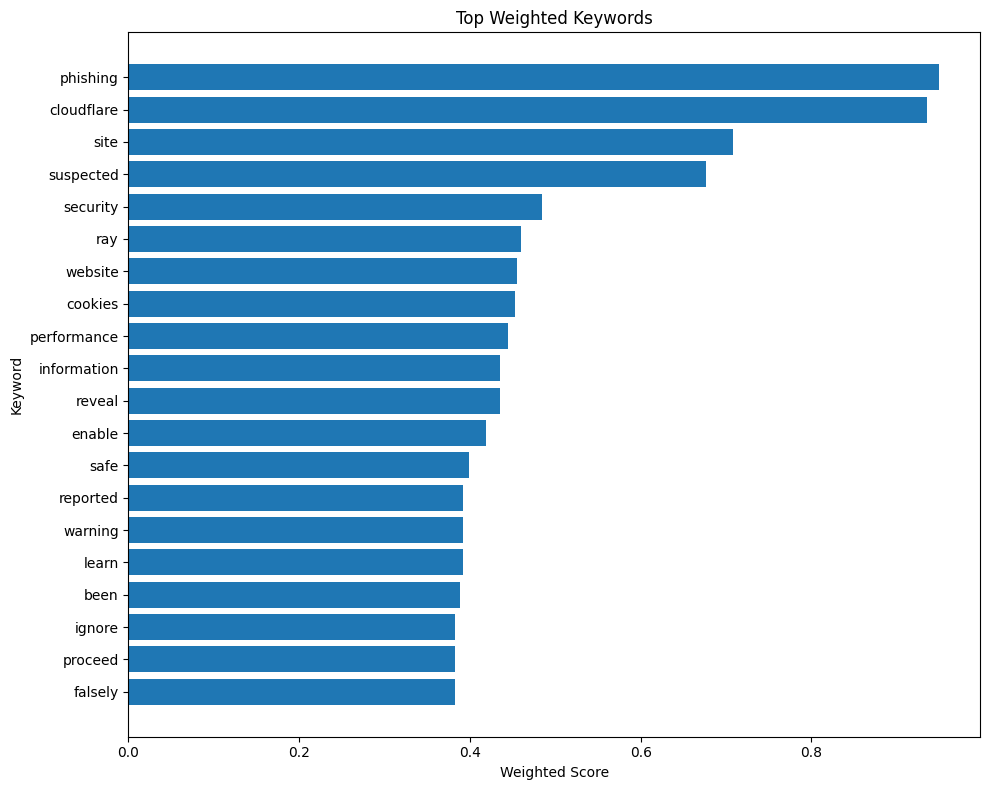

In [ ]:
# 画图：权重前20
import matplotlib.pyplot as plt

top20 = df_words.head(20).sort_values("final_score")

plt.figure(figsize=(10, 8))
plt.barh(top20["word"], top20["final_score"])
plt.xlabel("Weighted Score")
plt.ylabel("Keyword")
plt.title("Top Weighted Keywords")
plt.tight_layout()
plt.show()

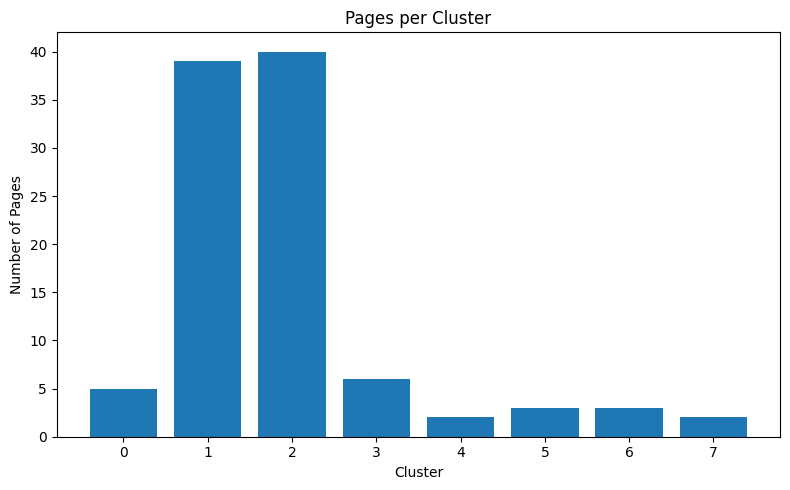

In [ ]:
cluster_counts = df_pages["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.xlabel("Cluster")
plt.ylabel("Number of Pages")
plt.title("Pages per Cluster")
plt.tight_layout()
plt.show()